# Agricultural Feed Recommendation Engine
### Chickwts Dataset — Group M4, Group 14

## Project scenario 

An agricultural supply company wants to recommend similar feed types to farmers based on performance data.

Using the chicken weights dataset as a proxy, you'll build a recommendation system that leverages PCA and similarity metrics to suggest comparable feed products that might produce similar results.

Using the `chickwts` dataset as a proxy — six feed types, each with a sample of resulting chick
weights — this notebook builds a data-driven feed recommendation engine.


## Step 0: Setting up - Import Libraries

In [33]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution shape statistics
from scipy.stats import skew, kurtosis

# PCA and similarity (the actual recommendation engine)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

np.random.seed(42)
sns.set_style("whitegrid")

## Step 1: Loading and Exploring the Data

In [34]:
# Load the Chickwts CSV file
chickwts = pd.read_csv('chickwts.csv')
chickwts.head()

,rownames,weight,feed
0,1,179,horsebean
1,2,160,horsebean
2,3,136,horsebean
3,4,227,horsebean
4,5,217,horsebean


In [35]:
print("Dataset shape:", chickwts.shape)
print("\nColumns:", chickwts.columns.tolist())
print("\nMissing values:\n", chickwts.isnull().sum())
print("\nFeed types:", sorted(chickwts['feed'].unique()))
print("\nObservations per feed:\n", chickwts['feed'].value_counts())

Dataset shape: (71, 3)

Columns: ['rownames', 'weight', 'feed']

Missing values:
 rownames    0
weight      0
feed        0
dtype: int64

Feed types: ['casein', 'horsebean', 'linseed', 'meatmeal', 'soybean', 'sunflower']

Observations per feed:
 feed
soybean      14
linseed      12
sunflower    12
casein       12
meatmeal     11
horsebean    10
Name: count, dtype: int64


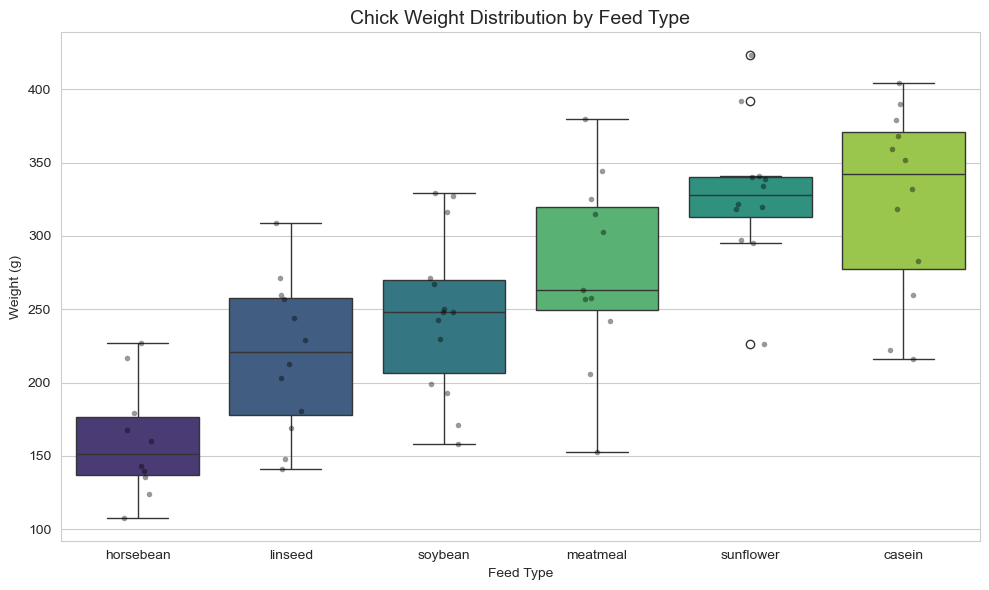

In [36]:
plt.figure(figsize=(10, 6))
order = chickwts.groupby('feed')['weight'].median().sort_values().index
sns.boxplot(x='feed', y='weight', data=chickwts, order=order, hue='feed', palette='viridis', legend=False)
sns.stripplot(x='feed', y='weight', data=chickwts, order=order, color='black', alpha=0.4, size=4)
plt.title('Chick Weight Distribution by Feed Type', fontsize=14)
plt.xlabel('Feed Type')
plt.ylabel('Weight (g)')
plt.tight_layout()
plt.show()


# Step 2: The Recommendation Engine — PCA + Cosine Similarity

## Feature Engineering — Building a Profile for Each Feed

Each feed is described by a numeric profile summarizing its weight distribution's central tendency,
spread, and shape. Note **sample size (`count`) is intentionally excluded** — it reflects how many
chicks happened to receive that feed in the study, not how the feed performs, and including it would
let an irrelevant variable influence which feeds get recommended as similar.

In [37]:
feed_profiles = chickwts.groupby('feed')['weight'].agg(
    mean_weight='mean',
    median_weight='median',
    std_weight='std',
    min_weight='min',
    max_weight='max',
    q25_weight=lambda x: x.quantile(0.25),
    q75_weight=lambda x: x.quantile(0.75),
).reset_index()

# Distribution shape: skewness (asymmetry) and kurtosis (tail heaviness)
feed_profiles['skew_weight'] = chickwts.groupby('feed')['weight'].apply(lambda x: skew(x)).values
feed_profiles['kurtosis_weight'] = chickwts.groupby('feed')['weight'].apply(lambda x: kurtosis(x)).values

# Coefficient of variation: spread relative to the mean
feed_profiles['cv_weight'] = feed_profiles['std_weight'] / feed_profiles['mean_weight']

feed_profiles

,feed,mean_weight,median_weight,std_weight,min_weight,max_weight,q25_weight,q75_weight,skew_weight,kurtosis_weight,cv_weight
0,casein,323.583333,342.0,64.433840,216,404,277.25,370.75,-0.524862,-1.064850,0.199126
1,horsebean,160.200000,151.5,38.625841,108,227,137.00,176.25,0.551319,-0.771063,0.241110
2,linseed,218.750000,221.0,52.235698,141,309,178.00,257.75,0.010586,-1.014334,0.238792
3,meatmeal,276.909091,263.0,64.900623,153,380,249.50,320.00,-0.282758,-0.495510,0.234375
4,soybean,246.428571,248.0,54.129068,158,329,206.75,270.00,0.031232,-0.882849,0.219654
5,sunflower,328.916667,328.0,48.836384,226,423,312.75,340.25,-0.061816,0.640547,0.148476


## Step 3: Standardize the Features

The profile mixes statistics on very different scales (e.g. `mean_weight` in the hundreds vs.
`cv_weight` as a small fraction). Standardizing puts every feature on equal footing before PCA and
similarity calculations.

In [38]:
feature_cols = [c for c in feed_profiles.columns if c != 'feed']
X = feed_profiles[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled, columns=feature_cols, index=feed_profiles['feed']).round(2)

,mean_weight,median_weight,std_weight,min_weight,max_weight,q25_weight,q75_weight,skew_weight,kurtosis_weight,cv_weight
feed,,,,,,,,,,
casein,1.09,1.29,1.17,1.18,0.89,0.85,1.28,-1.45,-0.80,-0.45
horsebean,-1.68,-1.67,-1.68,-1.42,-1.79,-1.51,-1.77,1.81,-0.30,0.85
linseed,-0.68,-0.59,-0.18,-0.63,-0.55,-0.82,-0.49,0.17,-0.71,0.78
meatmeal,0.30,0.06,1.22,-0.34,0.52,0.38,0.48,-0.72,0.18,0.64
soybean,-0.22,-0.17,0.03,-0.22,-0.25,-0.34,-0.30,0.23,-0.49,0.19
sunflower,1.18,1.07,-0.55,1.42,1.17,1.44,0.80,-0.05,2.12,-2.01


## Step 4: PCA Dimensionality Reduction

Several of these statistics are correlated with each other (a feed with a high mean often also has a
high max, for instance). PCA compresses the 10 correlated features into a smaller set of components
that capture most of the variance — this denoises the profile and lets us visualize the feed
landscape in 2D.

Explained variance ratio per component: [0.776 0.192 0.03 ]
Cumulative explained variance: [0.776 0.968 0.998]


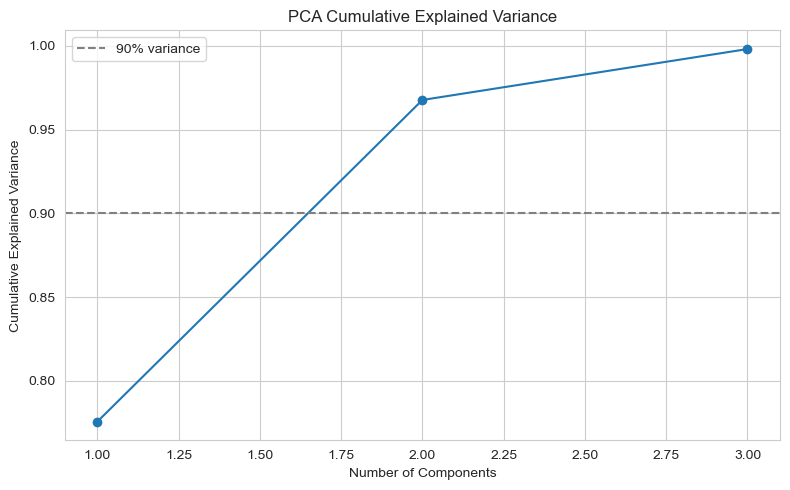

In [39]:
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio per component:", np.round(pca.explained_variance_ratio_, 3))
print("Cumulative explained variance:", np.round(np.cumsum(pca.explained_variance_ratio_), 3))

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(0.9, color='gray', linestyle='--', label='90% variance')
plt.title('PCA Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

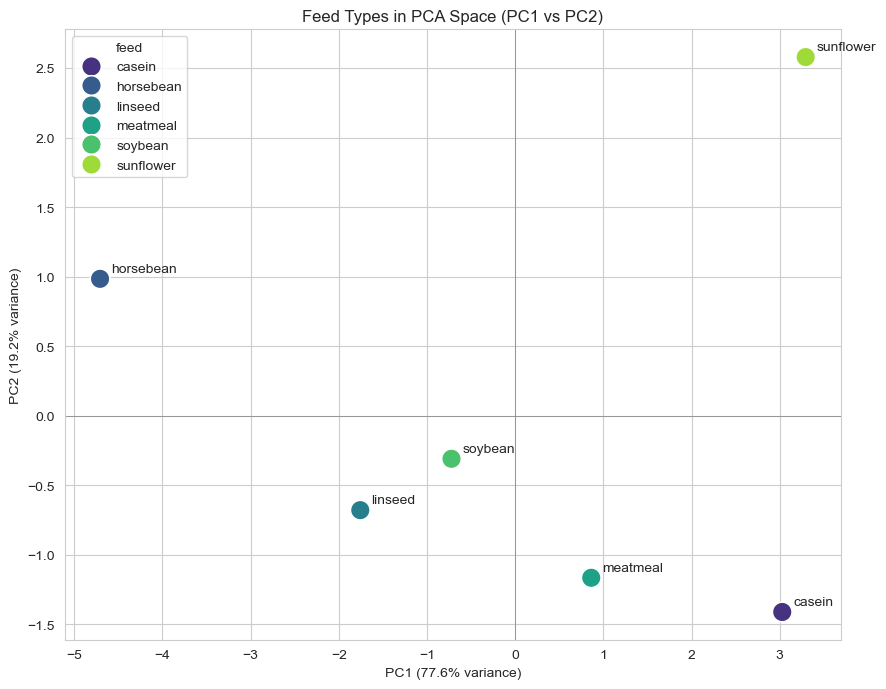

In [40]:
pca_df = pd.DataFrame(X_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['feed'] = feed_profiles['feed'].values

plt.figure(figsize=(9, 7))
sns.scatterplot(x='PC1', y='PC2', hue='feed', data=pca_df, s=200, palette='viridis')
for _, row in pca_df.iterrows():
    plt.annotate(row['feed'], (row['PC1'], row['PC2']), textcoords="offset points", xytext=(8, 5), fontsize=10)
plt.title('Feed Types in PCA Space (PC1 vs PC2)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()

## Step 5: Computing Feed-to-Feed Similarity

**This is the key fix from the original notebook.** Cosine similarity is computed on `X_pca` — the
PCA-transformed features — not on the pre-PCA scaled features. This makes the similarity matrix
actually reflect the reduced-noise representation that was just visualized, rather than silently
falling back to the raw standardized features.

In [41]:
similarity_matrix = cosine_similarity(X_pca)
similarity_df = pd.DataFrame(similarity_matrix, index=feed_profiles['feed'], columns=feed_profiles['feed'])
similarity_df.round(3)

feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.000,-0.945,-0.666,0.555,-0.570,0.438
horsebean,-0.945,1.000,0.839,-0.613,0.796,-0.645
linseed,-0.666,0.839,1.000,-0.243,0.975,-0.956
meatmeal,0.555,-0.613,-0.243,1.000,-0.340,-0.008
soybean,-0.570,0.796,0.975,-0.340,1.000,-0.937
sunflower,0.438,-0.645,-0.956,-0.008,-0.937,1.000


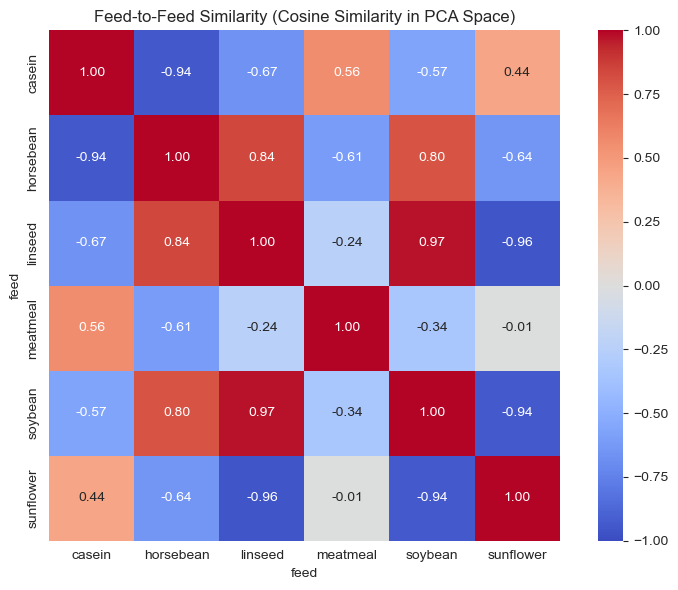

In [42]:
plt.figure(figsize=(8, 6))
sns.heatmap(similarity_df, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True)
plt.title('Feed-to-Feed Similarity (Cosine Similarity in PCA Space)')
plt.tight_layout()
plt.show()

## Step 6: The Recommendation Function

In [43]:
def recommend_feed(feed_name, similarity_df, feed_profiles_df, n=3):
    """
    Recommend the top-N feeds most similar to a given feed, with their performance stats.

    Parameters:
    -----------
    feed_name : str
        Name of the feed the farmer currently uses
    similarity_df : pd.DataFrame
        Square similarity matrix (feeds x feeds), computed in PCA space
    feed_profiles_df : pd.DataFrame
        Feed profile table (must contain a 'feed' column)
    n : int, default=3
        Number of similar feeds to recommend

    Returns:
    --------
    pd.DataFrame indexed by feed, with similarity score and key performance stats,
    sorted by similarity in descending order. None if feed_name isn't found.
    """
    if feed_name not in similarity_df.index:
        print(f"Feed '{feed_name}' not found. Available feeds: {list(similarity_df.index)}")
        return None

    # Similarity scores to every other feed, excluding itself, sorted descending
    scores = similarity_df.loc[feed_name].drop(feed_name).sort_values(ascending=False).head(n)

    # Attach performance stats for context
    result = feed_profiles_df.set_index('feed').loc[
        scores.index, ['mean_weight', 'std_weight', 'median_weight']
    ].copy()
    result.insert(0, 'similarity', scores.round(3))

    return result

In [44]:
# Test for every feed type
for feed in feed_profiles['feed']:
    top = recommend_feed(feed, similarity_df, feed_profiles, n=2)
    matches = ", ".join(f"{name} ({row.similarity:.2f})" for name, row in top.iterrows())
    print(f"Farmers using {feed:<10} -> try instead: {matches}")

Farmers using casein     -> try instead: meatmeal (0.56), sunflower (0.44)
Farmers using horsebean  -> try instead: linseed (0.84), soybean (0.80)
Farmers using linseed    -> try instead: soybean (0.97), horsebean (0.84)
Farmers using meatmeal   -> try instead: casein (0.56), sunflower (-0.01)
Farmers using soybean    -> try instead: linseed (0.97), horsebean (0.80)
Farmers using sunflower  -> try instead: casein (0.44), meatmeal (-0.01)


In [45]:
# Example: a farmer currently using 'soybean' wants alternatives
recommend_feed('soybean', similarity_df, feed_profiles, n=3)

,similarity,mean_weight,std_weight,median_weight
feed,,,,
linseed,0.975,218.750000,52.235698,221.0
horsebean,0.796,160.200000,38.625841,151.5
meatmeal,-0.340,276.909091,64.900623,263.0


## Conclusion

- **Linseed and soybean are strong substitutes** (similarity ≈ 0.98) — both produce moderate,
  similarly-shaped weight distributions. A farmer satisfied with one can confidently switch to the
  other if supply is constrained.
- **Casein and sunflower** cluster together as the higher-weight-gain group, and are close substitutes
  for farmers optimizing for growth.
- **Horsebean** stands apart, consistently producing the lowest weights, and is correctly never
  recommended as a substitute for the higher-performing feeds.
